In [1]:
import em2d

em2d.build_info()

em2d.sys_info()

Running cmake --build & --install in /home/zamb/zpic-parallel/cuda/python/build/cp310-cp310-linux_x86_64
zpic 
  build type : Release
  compiler   : GNU 11.4.0
  C++ std    : 17
  CXX flags  : 
Device Number           : 0
  Device name           : NVIDIA A100 80GB PCIe
  Max. block size       : 1024
  Warp size             : 32
  Max. warps/block      : 32
  Shared memory (def.)  : 48 (kB) 
  Shared memory (optin) : 163 (kB) 


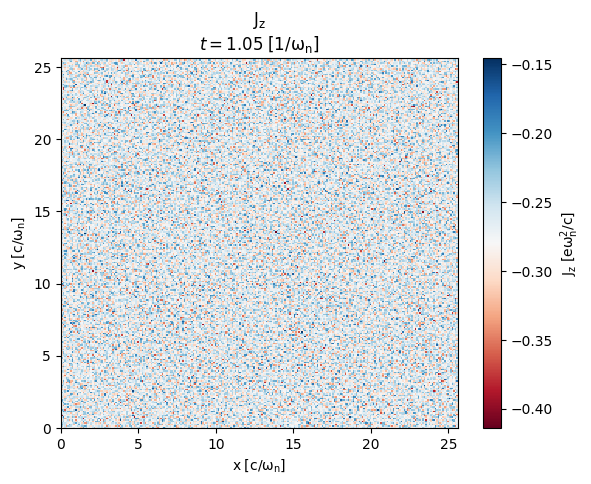

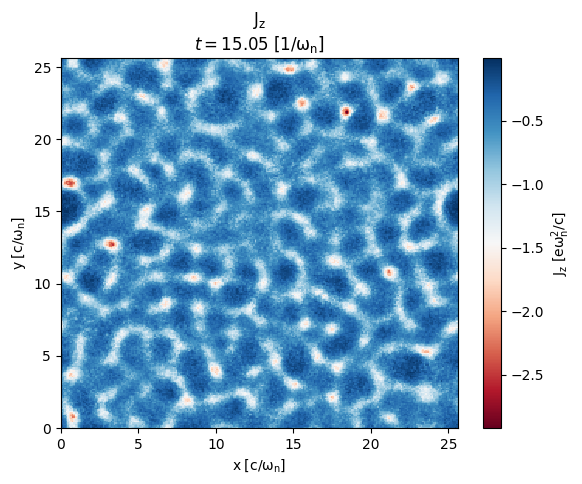

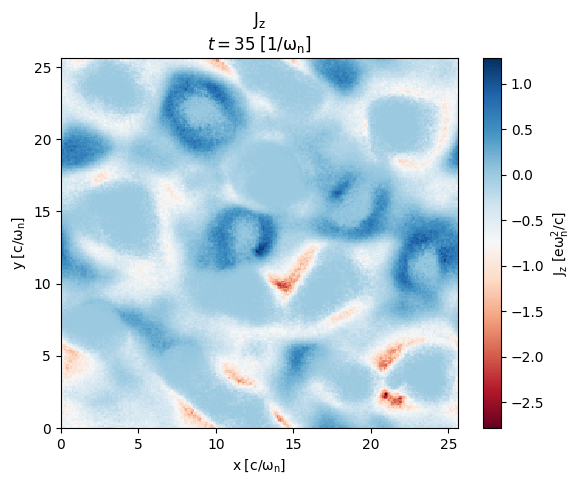

Simulation run up to t = 35.00000014901161


In [2]:
import em2d

# Grid parameters
dims   = ( 256, 256 )
ntiles = ( 16, 16 )
box = ( 0.1 * dims[0], 0.1 * dims[1] )

# Simulation time
tmax   = 35.0

# Particle species
electrons = em2d.Species( "electrons", -1, [4,4], 
                           udist = em2d.udist.ThermalCorr( [0.1, 0.1, 0.1], [ 0, 0, +0.6 ] ) )

positrons = em2d.Species( "positrons", +1, [4,4], 
                           udist = em2d.udist.ThermalCorr( [0.1, 0.1, 0.1], [ 0, 0, -0.6 ] ) )


# Create simulation object
nx = ( dims[0]//ntiles[0], dims[1]//ntiles[1] ) # nx must be integer
dt = 0.07
sim = em2d.Simulation( ntiles, nx, box, dt, species = [ electrons, positrons ] )

# Iterate up to tmax
while sim.t < 1:
    sim.advance()


sim.current.plot( 'z', cmap = "RdBu" )

while sim.t < 15:
    sim.advance()

sim.current.plot( 'z', cmap = "RdBu" )

while sim.t < 35:
    sim.advance()

sim.current.plot( 'z', cmap = "RdBu" )
# electrons.plot_charge( vmin = -5.5, vmax = 0, cmap = "plasma" )


print( "Simulation run up to t = {}".format(sim.t))

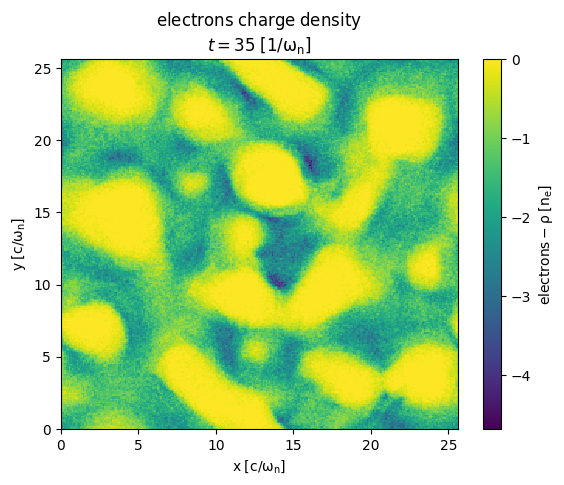

In [3]:
# electrons.plot('x','y')
electrons.plot_charge()

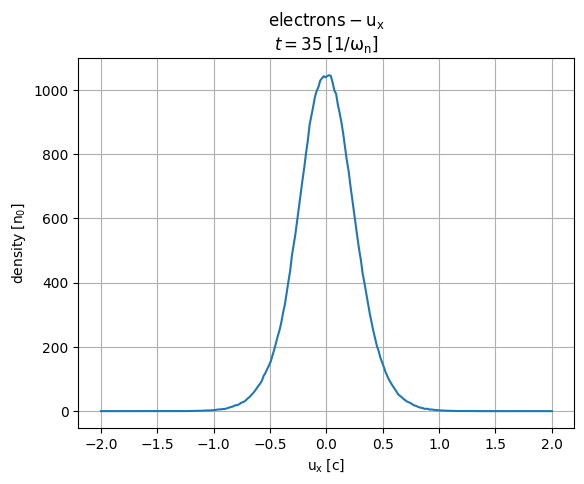

In [4]:
electrons.plot_phasespace( 'ux', (-2,2), 256 )

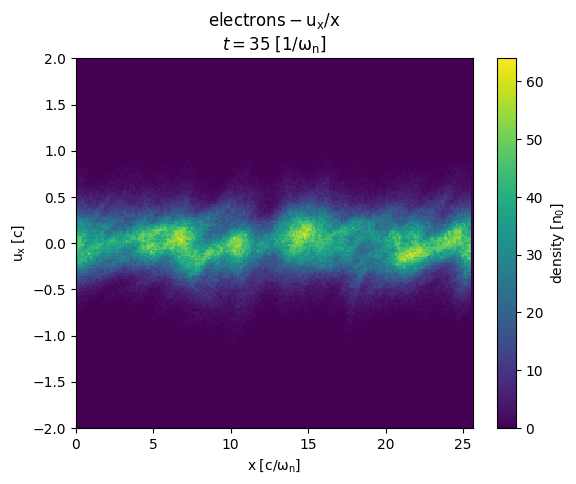

In [5]:
electrons.plot_phasespace( 'x', (0,25.6), 256, 'ux', (-2,2), 256 )